## Atenção: Este notebook não está documentado!
Todas as células de documentação foram removidas deste notebook, restando apenas as células de código com os respectivos resultados.

A documentação de código deve ser vista no notebook principal CVAE_CONV64_MIQR que possui a mesma estrutura de código que este notebook.

A única diferença é na célula "Modelo CVAE", que lá possui uma estrutura de rede CVAE sem fazer transfer learning da EfficientNet-B0.

In [ ]:
!pip install livelossplot monai torchmetrics torchinfo timm gdown optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 210.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found e

In [ ]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                NormalizeIntensity, RandFlip, ToTensor, Compose, ScaleIntensityRange, Lambda)

from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
from torchvision.models import mobilenet_v2
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score
import joblib
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(0)
set_determinism(seed=0)
print_config()

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/la

In [ ]:
!gdown 1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6 -O /content/training.zip

Downloading...
From (original): https://drive.google.com/uc?id=1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6
From (redirected): https://drive.google.com/uc?id=1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6&confirm=t&uuid=f6cb308b-fc7a-4574-b9e9-f550e067af1c
To: /content/training.zip
100% 338M/338M [00:01<00:00, 170MB/s]


In [ ]:
!unzip -q training.zip -d /content/
!gdown 1cYpxj2Lnmps3Mk7r0ObV54q2CmRu0V1C -O /content/dataset/metadata.csv

Downloading...
From: https://drive.google.com/uc?id=1cYpxj2Lnmps3Mk7r0ObV54q2CmRu0V1C
To: /content/dataset/metadata.csv
100% 2.51M/2.51M [00:00<00:00, 212MB/s]


In [ ]:
model_name = './models/CVAE_EFFI64_MIQR.pth'
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [ ]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))


Train count = 1067
Val count = 234
Test count = 267


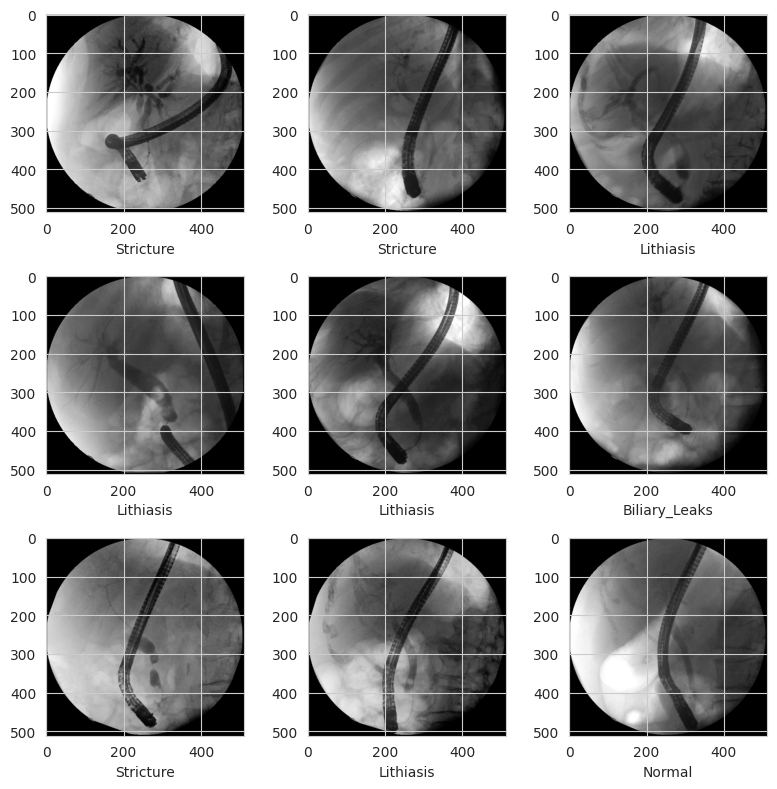

In [ ]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


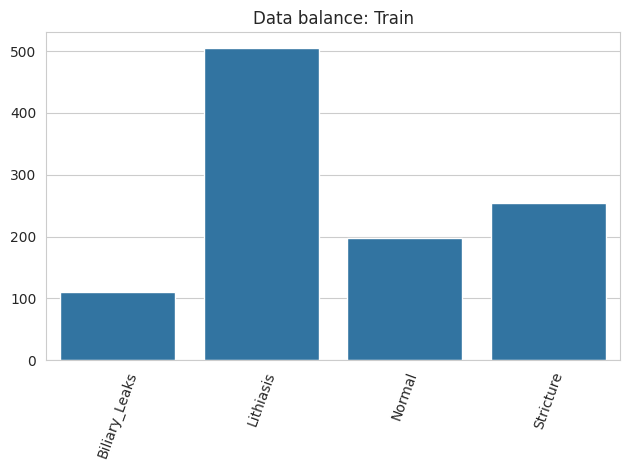

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


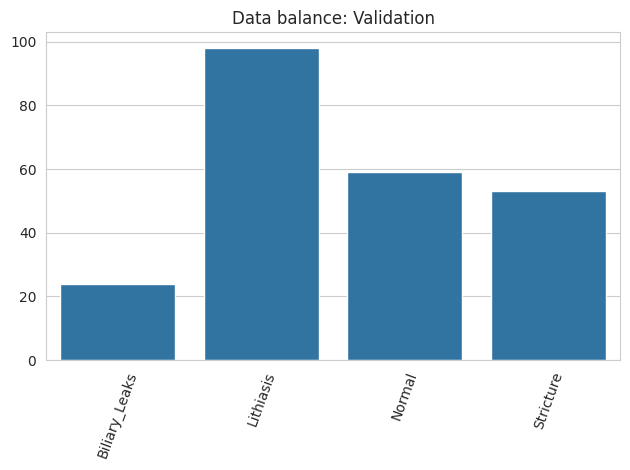

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


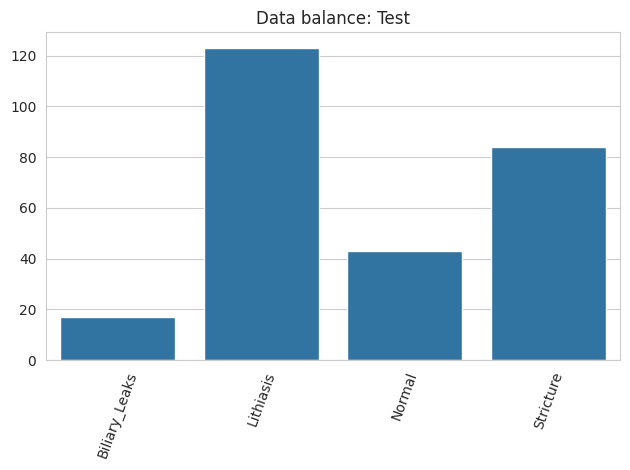

In [ ]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [ ]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    #RandFlip(spatial_axis=1,prob=0.5), # Data augmentation
    RandRotate(range_x=0.17,prob=0.5,padding_mode="border"), # ~10 graus
    RandZoom(min_zoom=0.9,max_zoom=1.1,prob=0.5),
    RandAdjustContrast(prob=0.5,gamma=(0.9, 1.1)),
    RandGaussianNoise(prob=0.2,mean=0.0,std=0.01),
    #NormalizeIntensity(),
    ScaleIntensityRange(a_min=0,a_max=255,b_min=0.0,b_max=1.0,clip=True), # Intensidade
    Lambda(repeat_if_needed), # grayscale -> RGB se necessário
    #NormalizeIntensity(subtrahend=[0.485, 0.456, 0.406],divisor=[0.229, 0.224, 0.225],channel_wise=True), # Normalize ImageNet EfficientNet-B0
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    #NormalizeIntensity(),
    ScaleIntensityRange(a_min=0,a_max=255,b_min=0.0,b_max=1.0,clip=True),
    Lambda(repeat_if_needed),
    #NormalizeIntensity(subtrahend=[0.485, 0.456, 0.406],divisor=[0.229, 0.224, 0.225],channel_wise=True),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [ ]:
metadata_path = os.path.join(base_dir, 'metadata.csv')
metadata_df = pd.read_csv(metadata_path)
# Extract relevant columns
metadata_features = metadata_df[['processed_image_path', 'age', 'sex', 'equipment_model', 'patient_id']]
metadata_features['processed_image_path'] = metadata_features['processed_image_path'].str.replace('processed/', '', regex=False)
display(metadata_features.head())

/tmp/ipykernel_556/2770275101.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_features['processed_image_path'] = metadata_features['processed_image_path'].str.replace('processed/', '', regex=False)


,processed_image_path,age,sex,equipment_model,patient_id
0,1_image1.png,69.0,M,Ziehm Vision RFD,1
1,1_image2.png,69.0,M,Ziehm Vision RFD,1
2,1_image3.png,69.0,M,Ziehm Vision RFD,1
3,1_image4.png,69.0,M,Ziehm Vision RFD,1
4,2_image5.png,96.0,F,Ziehm Vision RFD,2


In [ ]:
def limpar_nome(c):
    nome = c.split('/')[-1]
    p = nome.split('_', 1)[1]
    if p.startswith("image"):
      p = nome
    return p

image_names = []
for caminho in data['train']['images']:
    image_names.append(limpar_nome(caminho))
for caminho in data['val']['images']:
    image_names.append(limpar_nome(caminho))
for caminho in data['test']['images']:
    image_names.append(limpar_nome(caminho))

# Dicionários
age_dict = metadata_features.set_index('processed_image_path')['age'].to_dict()
sex_dict = metadata_features.set_index('processed_image_path')['sex'].to_dict()
eqp_dict = metadata_features.set_index('processed_image_path')['equipment_model'].to_dict()
pid_dict = metadata_features.set_index('processed_image_path')['patient_id'].to_dict()

# Mapeamento de sexo
sex_map = {'M': 1, 'F': 0}
eqp_map = {'PCR Eleva': 0, 'Ziehm Vision RFD': 1, 'Ziehm Vision RFD 3D': 2}

In [ ]:
BATCH_SIZE = 16

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

        image_names = list(map(limpar_nome, image_files))
        self.ages = [float(age_dict.get(nome)) if age_dict.get(nome) is not None else None
                for nome in image_names]
        self.sex_encoded = [sex_map.get(sex_dict.get(nome)) for nome in image_names]
        self.eqp_encoded = [eqp_map.get(eqp_dict.get(nome)) for nome in image_names]
        self.eqp_encoded = [eqp_map.get(eqp_dict.get(nome)) if eqp_map.get(eqp_dict.get(nome)) is not None else 1
                for nome in image_names]
        self.patient_ids = [int(pid_dict.get(nome)) if pid_dict.get(nome) is not None else None
          for nome in image_names]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index], self.ages[index], self.sex_encoded[index], self.eqp_encoded[index], self.patient_ids[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0)

x, y, _, _, _, _ = next(iter(train_ds)) #fazer uma iteração nos loaders para ir buscar um batch de casos
print(f"x min={x.min().item():.6f} max={x.max().item():.6f}")

x min=0.000000 max=1.000000


In [ ]:
# --- Create train_loader_noUnlabel ---
# Find the index of the 'Unlabelled' class
if 'Unlabelled' in class_names:
    unlabelled_class_idx = class_names.index('Unlabelled')

    # Filter out 'Unlabelled' samples from the training data
    train_images_no_unlabel = []
    train_labels_no_unlabel = []

    for img_path, label in zip(data['train']['images'], data['train']['labels']):
        if label != unlabelled_class_idx:
            train_images_no_unlabel.append(img_path)
            train_labels_no_unlabel.append(label)

    print(f"Original train samples: {len(data['train']['images'])}")
    print(f"Train samples without 'Unlabelled': {len(train_images_no_unlabel)}")

    # Create a new dataset and dataloader for training without 'Unlabelled' samples
    train_ds_no_unlabel = MedNISTDataset(train_images_no_unlabel, train_labels_no_unlabel, train_transforms)
    train_loader_noUnlabel = DataLoader(train_ds_no_unlabel, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
else:
    train_ds_no_unlabel = train_ds
    train_loader_noUnlabel = train_loader



## Modelo CVAE

In [ ]:
import torch
import torch.nn as nn
from torch.nn import Module
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights


class CVAE_EFFICIENTNET_B0(Module):

    def __init__(self,c_dim=4,z_dim=64,pretrained=True,freeze_backbone=True):
        super(CVAE_EFFICIENTNET_B0, self).__init__()
        self.c_dim = c_dim
        self.z_dim = z_dim
        # =========================================================
        # Encoder - EfficientNet B0
        if pretrained:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        else:
            weights = None

        backbone = efficientnet_b0(weights=weights)
        # remove classifier
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        # freeze backbone initially
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        # EfficientNet-B0 output = 1280 features
        self.fc_mu = nn.Linear(1280, z_dim)
        self.fc_log_var = nn.Linear(1280, z_dim)
        # =========================================================
        # Decoder: z + label
        self.fc_decoder = nn.Linear(
            z_dim + c_dim,
            256 * 8 * 8
        )
        self.decoder_layers = nn.Sequential(
			# 8x8 -> 16x16
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),
            nn.Conv2d(256, 256, 3, padding=1),   # extra refinement
            nn.BatchNorm2d(256),
            nn.SiLU(),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            # 64x64 -> 128x128
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            # 128x128 -> 256x256
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            # 256x256 -> 512x512
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            # Final
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
		)

    def encoder(self, x):
        # EfficientNet output:
        # shape = (B, 1280)
        x = self.backbone(x)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var

    def extract_unconditional_features(self, x):
        x = self.backbone(x)
        mu = self.fc_mu(x)
        return mu

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decoder(self, z, c):
        # concat latent + condition
        z = torch.cat([z, c], dim=1)
        z = self.fc_decoder(z)
        z = z.view(-1, 256, 8, 8)
        z = self.decoder_layers(z)
        return z

    def forward(self, x, c):
        # encoder SEM y
        mu, log_var = self.encoder(x)
        sample = self.sampling(mu, log_var)
        # decoder COM y
        outputs = self.decoder(sample, c)
        return outputs, mu, log_var, sample

    # Fine tuning helper
    def unfreeze_last_blocks(self, num_blocks=2):
        # freeze everything
        for p in self.backbone.parameters():
            p.requires_grad = False
        # unfreeze last EfficientNet blocks
        for p in self.backbone.features[-num_blocks:].parameters():
            p.requires_grad = True
        # keep latent heads trainable
        for p in self.fc_mu.parameters():
            p.requires_grad = True
        for p in self.fc_log_var.parameters():
            p.requires_grad = True

    def freeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

In [ ]:
#device management
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

device = get_default_device()
print(device)

cuda


In [ ]:
from torchinfo import summary
model = CVAE_EFFICIENTNET_B0(c_dim=num_class).to(device)
#visualizar a rede
print(summary(model, input_size=[(BATCH_SIZE, 3,512,512), (BATCH_SIZE,num_class)], dtypes=[torch.float, torch.long], verbose=0))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 269MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
CVAE_EFFICIENTNET_B0                                         [16, 3, 512, 512]         --
├─EfficientNet: 1-1                                          [16, 1280]                --
│    └─Sequential: 2-1                                       [16, 1280, 16, 16]        --
│    │    └─Conv2dNormActivation: 3-1                        [16, 32, 256, 256]        (928)
│    │    └─Sequential: 3-2                                  [16, 16, 256, 256]        (1,448)
│    │    └─Sequential: 3-3                                  [16, 24, 128, 128]        (16,714)
│    │    └─Sequential: 3-4                                  [16, 40, 64, 64]          (46,640)
│    │    └─Sequential: 3-5                                  [16, 80, 32, 32]          (242,930)
│    │    └─Sequential: 3-6                                  [16, 112, 32, 32]         (543,148)
│    │    └─Sequential: 3-7                                  

In [ ]:
from torchvision.utils import save_image, make_grid

def visualize(input_imgs, output_imgs):
    input_imgs=input_imgs.permute((1, 2, 0))
    output_imgs=output_imgs.permute((1, 2, 0))
    plt.subplots(1,2, figsize=(10, 10))
    plt.subplot(1,2,1)
    plt.axis('off')
    plt.grid(visible=None)
    plt.title('Autoencoder Input')
    plt.imshow(input_imgs)
    plt.subplot(1,2,2)
    plt.axis('off')
    plt.grid(visible=None)
    plt.title('Autoencoder Output')
    plt.imshow(output_imgs)
    plt.show()

def test_image_reconstruction(model, test_dl):
    for img,cond, _, _, _, _ in test_dl:
        img = img.to(device)
        cond = one_hot(cond, num_class).to(device)
        outputs,_,_,_ = model(img,cond)
        outputs = outputs.view(outputs.size(0), 3, 512, 512).cpu().data
        inputs = img.cpu().data
        inputs = inputs[:16]
        outputs = outputs[:16]
        save_image(outputs, 'miqr_reconstruction_out.png')
        save_image(inputs, 'miqr_reconstruction_in.png')
        outputs = make_grid(outputs, nrow=4)
        inputs = make_grid(inputs, nrow=4)
        break
    return inputs, outputs

In [ ]:
from torch.autograd import Variable
#one-hot encoding
def one_hot(labels, class_size):
    targets = torch.zeros(labels.size(0), class_size)
    for i, label in enumerate(labels):
        targets[i, label] = 1
    return targets

def unfreeze_last_blocks(model, optimizer, lr, num_blocks=3):
    model.unfreeze_last_blocks(num_blocks)
    # Reduce learning rate for fine-tuning of backbone
    for param_group in optimizer.param_groups:
        if 'backbone' in str(param_group):
            param_group['lr'] = lr

#treino do modelo
def train_model(h5_file,train_dl, test_dl, model, loss_function, optimizer, scheduler, epochs, ini_epoch=0):
    liveloss = PlotLosses()
    best_loss = float('inf')

    if ini_epoch > 25 and UNFREEZE2 > 0:
        unfreeze_last_blocks(model, optimizer, LEARNING_RATE / 100.0, UNFREEZE2)
    elif ini_epoch > 12 and UNFREEZE1 > 0:
        unfreeze_last_blocks(model, optimizer, LEARNING_RATE / 20.0, UNFREEZE1)
    else:
        model.freeze_all()

    for epoch in range(ini_epoch, epochs):
        beta = 0.0 if epoch < 5 else min(0.005, (epoch - 5) / 10 * 0.005)
        if epoch == 12 and UNFREEZE1 > 0:
            unfreeze_last_blocks(model, optimizer, LEARNING_RATE / 20.0, UNFREEZE1)
        elif epoch == 25 and UNFREEZE2 > 2:
            unfreeze_last_blocks(model, optimizer, LEARNING_RATE / 100.0, UNFREEZE2)

        logs = {}
        model.train()
        running_loss  = 0.0
        for inputs, cond, _, _, _, _ in train_dl:
            inputs = inputs.to(device)
            cond = one_hot(cond, num_class).to(device)
            outputs, mu, log_var, _ = model(inputs, cond)
            loss, recon_loss, kl_loss = loss_function(outputs, inputs, mu, log_var,beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_dl.dataset)
        logs['loss'] = epoch_loss*1000 #.item()
        #Validation phase
        model.eval()
        running_loss  = 0.0
        for inputs, cond, _, _, _, _ in test_dl:
            inputs = inputs.to(device)
            cond = one_hot(cond, num_class).to(device)
            outputs, mu, log_var, _ = model(inputs, cond)
            loss, recon_loss, kl_loss = loss_function(outputs, inputs, mu, log_var,beta)
            running_loss += loss.item()
        epoch_loss = running_loss / len(test_dl.dataset)
        logs['val_loss'] = epoch_loss*1000 #.item()
        scheduler.step(epoch_loss) #callback a meio para atualizar lr
        epoch_lr = optimizer.param_groups[0]['lr']
        logs['val_lr'] = epoch_lr
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), h5_file)
        liveloss.update(logs) #para visualizarmos o processo de treino
        liveloss.send() #para visualizarmos o processo de treino
        inputs_ex, outputs_ex = test_image_reconstruction(model, test_loader)
        visualize(inputs_ex, outputs_ex)


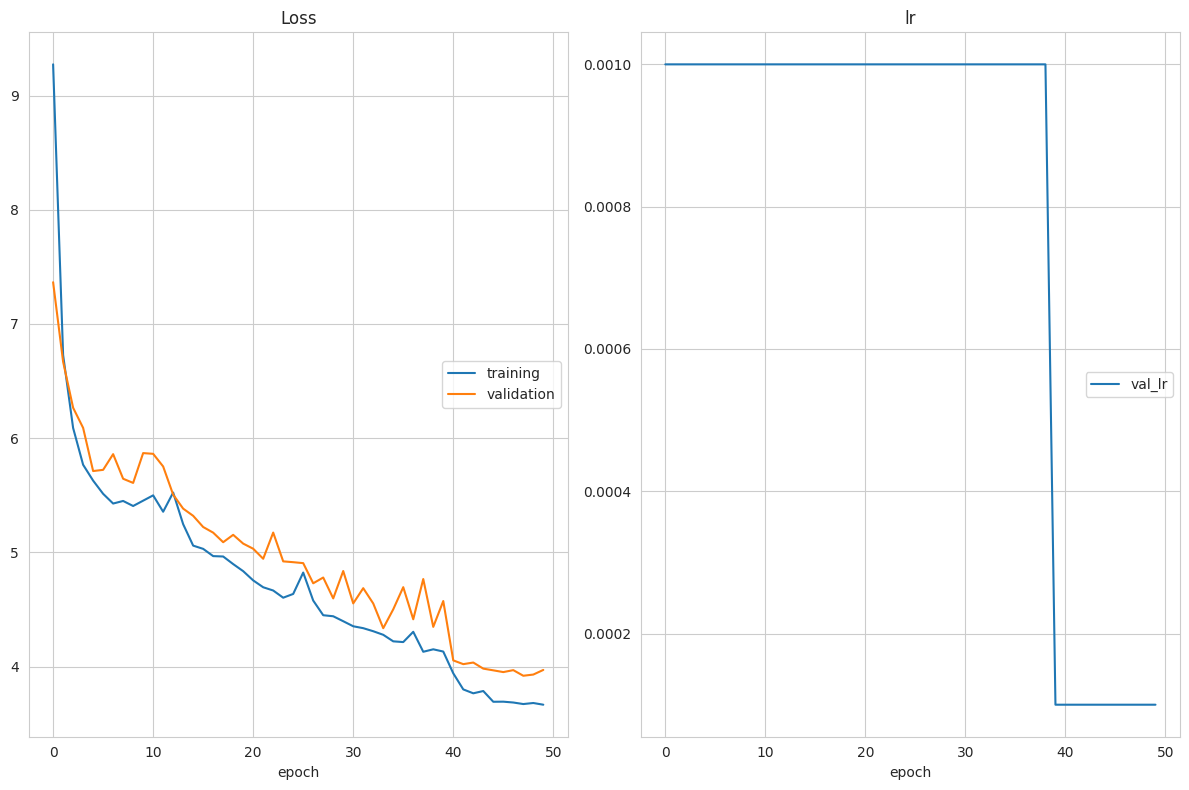

Loss
	training         	 (min:    3.666, max:    9.274, cur:    3.666)
	validation       	 (min:    3.919, max:    7.366, cur:    3.970)
lr
	val_lr           	 (min:    0.000, max:    0.001, cur:    0.000)
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([16, 3, 512, 512])
torch.Size([16, 3, 512, 512])
torch.Size([16, 3, 512, 512])


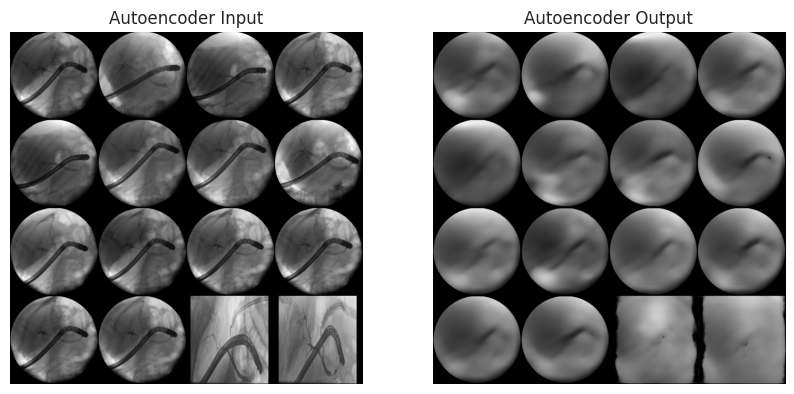

Tempo gasto: 6135.11315496 segundos


In [ ]:
initial_epoch = 0 #-1 indica que não é para treinar, simplesmente ler
EPOCHS = 50
LEARNING_RATE = 1e-3
UNFREEZE1 = 2
UNFREEZE2 = 4 if UNFREEZE1 > 0 else 0 # 0 é para desativar

def loss_function(recon_x,x,mu,log_var,beta=0.001):
    #VAE/CVAE loss Parameters: recon_x : reconstruc ted image / x       : original image / mu      : latent mean / log_var : latent log variance / beta    : KL weight
    # Reconstruction loss, L1 costuma funcionar melhor visualmente e gera menos blur que BCE/MSE
    recon_loss = F.l1_loss(recon_x,x,reduction='mean')
    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    if torch.isnan(kl_loss) or torch.isnan(recon_loss):
       print('Nan', recon_x.min(), recon_x.max(), x.min(), x.max())
    # Total loss
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

if initial_epoch >= 0:
    from torch.optim import SGD, Adam
    import torch.nn.functional as F
    from torch.optim.lr_scheduler import ReduceLROnPlateau
    import os # Import os module for path checking

    model = CVAE_EFFICIENTNET_B0(c_dim=num_class)
    if os.path.exists(model_name) and initial_epoch > 0:
        model.load_state_dict(torch.load(model_name, map_location='cpu', weights_only=True))
    else:
        print(f"Model file not found at {model_name}. Training a new model.")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5)
    starttime = time.perf_counter()
    train_model(model_name, train_loader, val_loader, model, loss_function, optimizer, scheduler, EPOCHS, initial_epoch)
    endtime = time.perf_counter()
    print(f"Tempo gasto: {endtime - starttime} segundos")

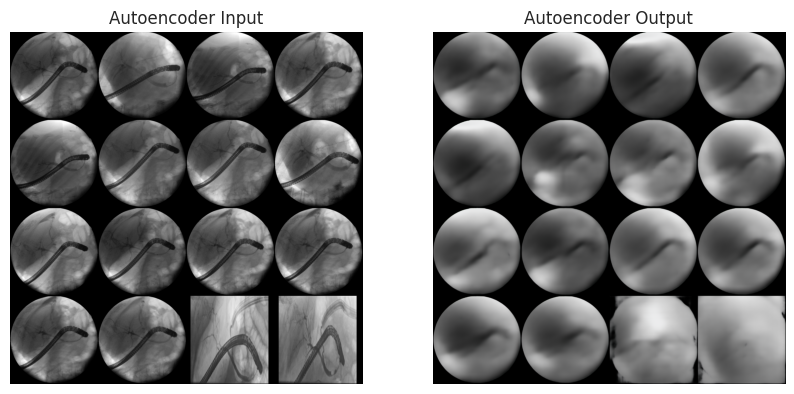

In [ ]:
model = CVAE_EFFICIENTNET_B0(c_dim=num_class)
model.load_state_dict(torch.load(model_name, map_location='cpu', weights_only=True))
model.to(device) # Move model to the correct device after loading state dict
inputs, outputs = test_image_reconstruction(model, test_loader)
visualize(inputs, outputs)

In [ ]:
load_features = False

def load_features_list():
    # Load the combined data from the .joblib file
    combined_data_path = model_name.replace("/CVAE", "/ExtractedFeat").replace(".pth", ".joblib")
    loaded_data = joblib.load(combined_data_path)

    # Unpack the data into individual variables
    train_features = loaded_data['train_features']
    train_labels = loaded_data['train_labels']
    val_features = loaded_data['val_features']
    val_labels = loaded_data['val_labels']
    test_features = loaded_data['test_features']
    test_labels = loaded_data['test_labels']

    print("Features and labels loaded successfully.")
    print(f"Train features shape: {train_features.shape}, Train labels shape: {train_labels.shape}")
    print(f"Validation features shape: {val_features.shape}, Validation labels shape: {val_labels.shape}")
    print(f"Test features shape: {test_features.shape}, Test labels shape: {test_labels.shape}")
    return train_features, val_features, test_labels

def extract_features(data_loader, model, device, load_features):
    features_list = []
    labels_list = []
    age_list = []
    sex_list = []
    eqp_list = []
    pid_list = []
    with torch.no_grad():
        for images, labels, f_age, f_sex, f_eqp, f_pid in data_loader:
            images = images.to(device)
            # Extract unconditional features using the CVAE encoder
            features = model.extract_unconditional_features(images)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
            age_list.append(f_age.cpu().numpy())
            sex_list.append(f_sex.cpu().numpy())
            eqp_list.append(f_eqp.cpu().numpy())
            pid_list.append(f_pid.cpu().numpy())
    return np.vstack(features_list), np.hstack(labels_list), np.hstack(age_list), np.hstack(sex_list), np.hstack(eqp_list), np.hstack(pid_list)

if load_features:
    train_features, val_features, test_labels = load_features_list()
else:
    # Load the trained CVAE model
    cvae_model = CVAE_EFFICIENTNET_B0(c_dim=num_class)
    cvae_model.load_state_dict(torch.load(model_name, map_location='cpu'))
    cvae_model.to(device)
    cvae_model.eval() # Set to evaluation mode

    print("CVAE model loaded successfully and set to evaluation mode.")

    # Extract features and labels for training, validation, and test sets
    print("Extracting training features...")
    train_features, train_labels, f_age, f_sex, f_eqp, f_pid = extract_features(train_loader_noUnlabel, cvae_model, device, load_features)
    train_features = np.vstack([np.hstack((np.array([num1, num2, num3]), sublista)) for num1, num2, num3, sublista in zip(f_age, f_sex, f_eqp, train_features)])
    print(f"Training features shape: {train_features.shape}, Training labels shape: {train_labels.shape}")

    print("Extracting validation features...")
    val_features, val_labels, f_age, f_sex, f_eqp, f_pid = extract_features(val_loader, cvae_model, device, load_features)
    val_features = np.vstack([np.hstack((np.array([num1, num2, num3]), sublista)) for num1, num2, num3, sublista in zip(f_age, f_sex, f_eqp, val_features)])
    print(f"Validation features shape: {val_features.shape}, Validation labels shape: {val_labels.shape}")

    print("Extracting test features...")
    test_features, test_labels, f_age, f_sex, f_eqp, f_pid = extract_features(test_loader, cvae_model, device, load_features)
    test_features = np.vstack([np.hstack((np.array([num1, num2, num3]), sublista)) for num1, num2, num3, sublista in zip(f_age, f_sex, f_eqp, test_features)])
    print(f"Test features shape: {test_features.shape}, Test labels shape: {test_labels.shape}")

    # Gather all features and labels into a dictionary
    data_to_save = {
        'train_features': train_features,
        'train_labels': train_labels,
        'val_features': val_features,
        'val_labels': val_labels,
        'test_features': test_features,
        'test_labels': test_labels
    }

    # Define a single path for the combined data
    combined_data_path = model_name.replace("/CVAE", "/ExtractedFeat").replace(".pth", ".joblib")
    joblib.dump(data_to_save, combined_data_path)
    print(f"All features and labels saved successfully to {combined_data_path}")

CVAE model loaded successfully and set to evaluation mode.
Extracting training features...
Training features shape: (1067, 67), Training labels shape: (1067,)
Extracting validation features...
Validation features shape: (234, 67), Validation labels shape: (234,)
Extracting test features...
Test features shape: (267, 67), Test labels shape: (267,)
All features and labels saved successfully to ./models/ExtractedFeat_EFFI64_MIQR.joblib


In [ ]:
load_XGB_model = False

import optuna
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import f1_score  # ou accuracy, balanced_accuracy

if load_XGB_model:
    # Define the path where the XGBoost model was saved
    xgboost_model_path = model_name.replace("/CVAE", "/XGB")
    # Load the XGBoost model
    loaded_xgboost_model = joblib.load(xgboost_model_path)
    print(f"XGBoost model loaded successfully from {xgboost_model_path}")

else:
    class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(train_labels),y=train_labels)
    class_weights_dict = {i : class_weights[i] for i in range(len(class_weights))}
    sample_weights = np.array([class_weights_dict[label] for label in train_labels])

    def objective(trial):
        params = {
            'objective': 'multi:softmax',
            'num_class': num_class,
            'eval_metric': 'mlogloss',
            'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
            'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 8),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
            'gamma': trial.suggest_float('gamma', 0.0, 0.5),
            'subsample': trial.suggest_float('subsample', 0.6, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'tree_method': 'hist',
            'early_stopping_rounds': 50,
            'device': 'cuda',
            'random_state': 42
        }

        model = xgb.XGBClassifier(**params)

        model.fit(
            train_features, train_labels,
            sample_weight=sample_weights,
            eval_set=[(val_features, val_labels)],

            verbose=False
        )

        pred_val = model.predict(val_features)
        score = f1_score(val_labels, pred_val, average='weighted')   # ou 'macro'

        return score

    # ====================== Rodar o Optuna ======================
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(objective, n_trials=60)        # 50~80 trials é bom para seu tamanho

    print("Melhores hiperparâmetros:", study.best_params)
    print("Melhor score:", study.best_value)

[I 2026-05-26 16:57:53,267] A new study created in memory with name: no-name-bfb94a1f-c169-4393-8718-cb9b1026ee0d
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:57:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-05-26 16:57:54,030] Trial 0 finished with value: 0.3251973801586175 and parameters: {'n_estimators': 1017, 'learning_rate': 0.04073029732157048, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 0.23684520534009557, 'subsample': 0.8653236080796408, 'colsample_bytree': 0.6660006556692126, 'reg_lambda': 1.8408863531191857, 'r

Melhores hiperparâmetros: {'n_estimators': 759, 'learning_rate': 0.010666645394907394, 'max_depth': 4, 'min_child_weight': 1, 'gamma': 0.1923092702759387, 'subsample': 0.9352329492915289, 'colsample_bytree': 0.8794520358278992, 'reg_lambda': 2.1849948570494635, 'reg_alpha': 0.3601597270427307}
Melhor score: 0.36984310962916894


Melhores hiperparâmetros encontrados:
  n_estimators: 759
  learning_rate: 0.010666645394907394
  max_depth: 4
  min_child_weight: 1
  gamma: 0.1923092702759387
  subsample: 0.9352329492915289
  colsample_bytree: 0.8794520358278992
  reg_lambda: 2.1849948570494635
  reg_alpha: 0.3601597270427307

Treinando modelo final com os melhores parâmetros...
Modelo final treinado com sucesso!
Melhor iteração: 61
XGBoost model saved successfully to ./models/XGB_EFFI64_MIQR.pth

Relatório de classificação no Validation Set:
              precision    recall  f1-score   support

           0       0.21      0.17      0.19        24
           1       0.49      0.61      0.55        98
           2       0.31      0.19      0.23        59
           3       0.25      0.26      0.25        53

    accuracy                           0.38       234
   macro avg       0.31      0.31      0.30       234
weighted avg       0.36      0.38      0.36       234

F1-Score (weighted): 0.3636


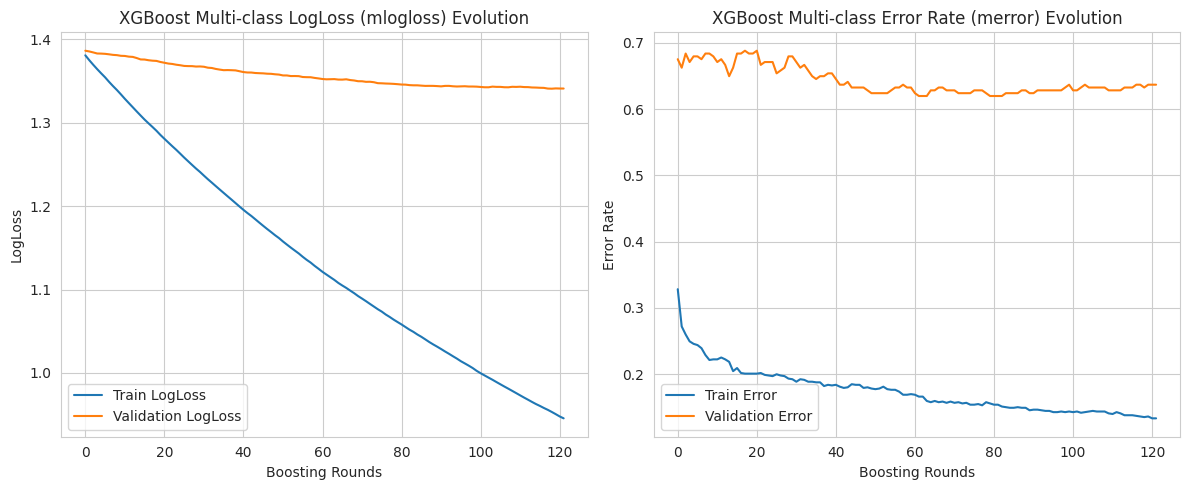

In [ ]:
if not load_XGB_model:
    best_params = study.best_params
    print("Melhores hiperparâmetros encontrados:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")

    # Adicionar parâmetros fixos importantes
    best_params['objective'] = 'multi:softmax'
    best_params['num_class'] = num_class
    best_params['eval_metric'] = ['mlogloss', 'merror']
    best_params['tree_method'] = 'hist'
    best_params['device'] = 'cuda'
    best_params['random_state'] = 42
    best_params['early_stopping_rounds'] = 60

    # ====================== TREINAR MODELO FINAL ======================
    print("\nTreinando modelo final com os melhores parâmetros...")

    xgboost_model = xgb.XGBClassifier(**best_params)

    xgboost_model.fit(
        train_features,
        train_labels,
        sample_weight=sample_weights,
        eval_set=[(train_features, train_labels), (val_features, val_labels)],
        verbose=False
    )

    evals_result = xgboost_model.evals_result()
    print("Modelo final treinado com sucesso!")
    print(f"Melhor iteração: {xgboost_model.best_iteration}")

    # Define the path to save the XGBoost model
    xgboost_model_path = model_name.replace("/CVAE", "/XGB")
    # Save the trained XGBoost model
    joblib.dump(xgboost_model, xgboost_model_path)
    print(f"XGBoost model saved successfully to {xgboost_model_path}")

        # ====================== AVALIAÇÃO ======================
    from sklearn.metrics import classification_report, confusion_matrix, f1_score

    pred_val = xgboost_model.predict(val_features)
    print("\nRelatório de classificação no Validation Set:")
    print(classification_report(val_labels, pred_val))

    print(f"F1-Score (weighted): {f1_score(val_labels, pred_val, average='weighted'):.4f}")

    # Plot the log loss (mlogloss) during training
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(evals_result['validation_0']['mlogloss'], label='Train LogLoss')
    plt.plot(evals_result['validation_1']['mlogloss'], label='Validation LogLoss')
    plt.title('XGBoost Multi-class LogLoss (mlogloss) Evolution')
    plt.xlabel('Boosting Rounds')
    plt.ylabel('LogLoss')
    plt.legend()
    plt.grid(True)

    # Plot the error rate (merror) during training
    plt.subplot(1, 2, 2)
    plt.plot(evals_result['validation_0']['merror'], label='Train Error')
    plt.plot(evals_result['validation_1']['merror'], label='Validation Error')
    plt.title('XGBoost Multi-class Error Rate (merror) Evolution')
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Error Rate')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Train Accuracy: 0.8341
Val Accuracy: 0.3803
Test Accuracy: 0.2959
Test Classification Report:
               precision    recall  f1-score   support

Biliary_Leaks     0.1176    0.1176    0.1176        17
    Lithiasis     0.4480    0.4553    0.4516       123
       Normal     0.1333    0.2326    0.1695        43
    Stricture     0.2200    0.1310    0.1642        84

     accuracy                         0.2959       267
    macro avg     0.2297    0.2341    0.2257       267
 weighted avg     0.3046    0.2959    0.2945       267

Test Confusion Matrix:
[[ 2 10  2  3]
 [ 7 56 35 25]
 [ 1 21 10 11]
 [ 7 38 28 11]]


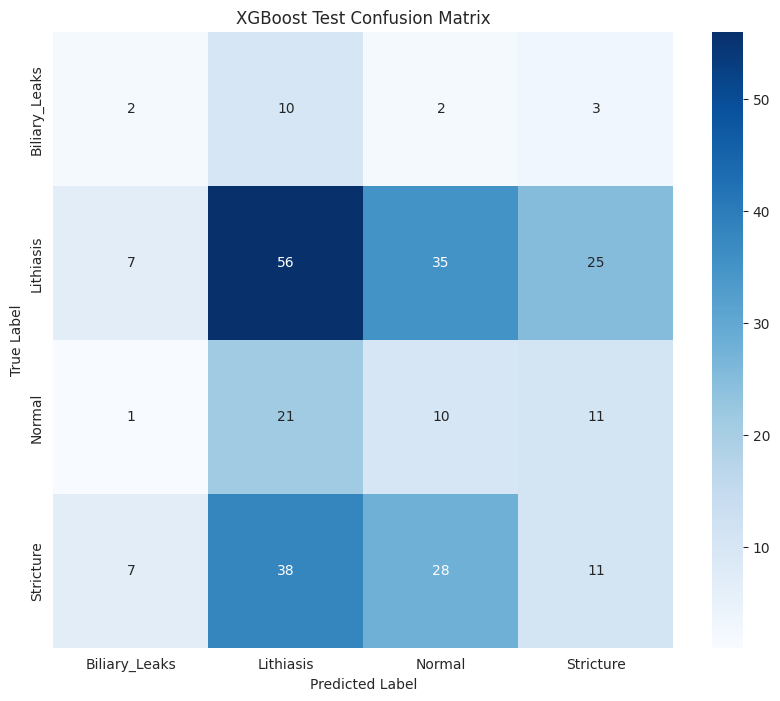

In [ ]:
# Make predictions on the train set
train_predictions = xgboost_model.predict(train_features)
train_accuracy = accuracy_score(train_labels, train_predictions)
print(f"Train Accuracy: {train_accuracy:.4f}")

# Make predictions on the val set
val_predictions = xgboost_model.predict(val_features)
val_accuracy = accuracy_score(val_labels, val_predictions)
print(f"Val Accuracy: {val_accuracy:.4f}")

# Make predictions on the test set
test_predictions = xgboost_model.predict(test_features)
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Display classification report
print("Test Classification Report:")
print(classification_report(test_labels, test_predictions, target_names=class_names, digits=4, zero_division=0))

# Display confusion matrix
test_cm = confusion_matrix(test_labels, test_predictions)
print("Test Confusion Matrix:")
print(test_cm)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(test_cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Test Confusion Matrix')
plt.show()

Original Image True Class: Biliary_Leaks
Predicted Class (based on CVAE reconstruction): Lithiasis
Minimum Reconstruction Loss: 1339275.00


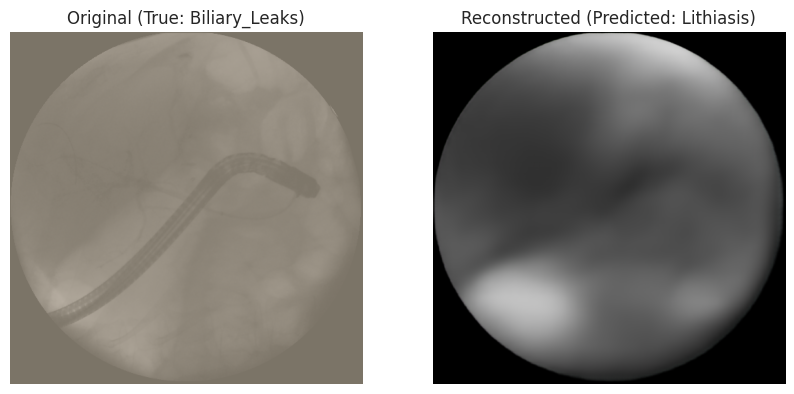

In [ ]:
import torch.nn.functional as F

def classify_unlabeled_image(model, image, num_classes, device):
    model.eval()  # Set the model to evaluation mode
    image = image.to(device) # Move image to the appropriate device
    best_loss = float('inf')
    predicted_class = -1

    # Iterate through each possible class
    for i in range(num_classes):
        # Create a one-hot encoded condition for the current class
        condition_label = torch.tensor([i], dtype=torch.long, device=device)
        condition_one_hot = one_hot(condition_label, num_classes).to(device)
        # Expand condition_one_hot to match the batch size of the image (if image is a single image, batch_size is 1)
        condition_one_hot = condition_one_hot.repeat(image.size(0), 1)

        # Pass the image and assumed condition through the CVAE
        with torch.no_grad(): # No need to calculate gradients for classification
            recon_x, mu, log_var, _ = model(image, condition_one_hot)

        current_loss = F.l1_loss(recon_x,image,reduction='mean')
        # If this class yields a better reconstruction, update the best_loss and predicted_class
        if current_loss < best_loss:
            best_loss = current_loss
            predicted_class = i

    return predicted_class, best_loss

# Get a sample unlabeled image from the test set
# For demonstration, we'll take the first image from the test_loader
for images, labels, _, _, _, _ in test_loader:
    sample_image = images[0].unsqueeze(0) # Get a single image and add batch dimension
    true_label = labels[0].item() # Get the true label for comparison
    break

# Define sample_image_display for plotting (reintroducing deleted code)
# The `sample_image` is already in [0,1] range due to transforms, so direct conversion is fine.
sample_image_display = sample_image.squeeze(0).cpu().permute(1, 2, 0)
sample_image_display = torch.clamp(sample_image_display, 0.0, 1.0)
# Ensure model is on the correct device before classification
model.to(device)

# Classify the unlabeled sample image
predicted_class_idx, min_recon_loss = classify_unlabeled_image(model, sample_image, num_class, device)
predicted_class_name = class_names[predicted_class_idx]
true_class_name = class_names[true_label]

print(f"Original Image True Class: {true_class_name}")
print(f"Predicted Class (based on CVAE reconstruction): {predicted_class_name}")
print(f"Minimum Reconstruction Loss: {min_recon_loss:.2f}")

# Visualize the original image and its reconstruction for the predicted class
# Create a one-hot encoded condition for the predicted class
predicted_condition_label = torch.tensor([predicted_class_idx], dtype=torch.long, device=device)
predicted_condition_one_hot = one_hot(predicted_condition_label, num_class).to(device)
predicted_condition_one_hot = predicted_condition_one_hot.repeat(sample_image.size(0), 1)

# Move sample_image to the correct device before using it in the model call
sample_image = sample_image.to(device)

with torch.no_grad():
    reconstructed_image, _, _, _ = model(sample_image, predicted_condition_one_hot)

reconstructed_image_cpu = reconstructed_image.squeeze(0).cpu().permute(1, 2, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_display)
plt.title(f"Original (True: {true_class_name})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_cpu)
plt.title(f"Reconstructed (Predicted: {predicted_class_name})")
plt.axis('off')
plt.show()